In [ ]:
###pyFIA Jupyter Notebook Demo###
# -*- coding: utf-8 -*-
#Credits
"""
Created on Mon Oct 28 08:34:18 2024
@author: xinyuan.wei, gregory.mchale
"""
# This notebook showcases a subset of pyFIA functions to illustrate different features of the code, using Oregon as the test case.

In [1]:
# Load in required packages
import pandas as pd
import geopandas as gpd

In [2]:
# Import supplementary Python scripts contained in larger pyFIA folder
# Ensure these scripts are in your working directory before running
import _pyFIA_Plot_Stats as ps
import _pyFIA_Regional_Stats as rs
import _pyFIA_Visualization as vl
import _pyFIA_Interpolation as ip
import _pyFIA_Climate as cl
import _pyFIA_Bookkeeping as bk

In [3]:
# Select desired state (postal code) and corresponding Federal Information Processing Standards (FIPS) code. 
# Ensure that state's FIA data is contained in your working directory. In this notebook, we will use Oregon (OR). 
State = 'OR'
FIPS = '41'
# Load the FIA Tree, Condition, Plot, County, Pop_stratum, Pop_Stratum_Assgn .csvs 
FIA_Data = {
    'tree_data': pd.read_csv(f'{State}_CSV/{State}_TREE.csv', low_memory=False),
    'cond_data': pd.read_csv(f'{State}_CSV/{State}_COND.csv', low_memory=False),
    'plot_data': pd.read_csv(f'{State}_CSV/{State}_PLOT.csv', low_memory=False),
    'coty_data': pd.read_csv(f'{State}_CSV/{State}_COUNTY.csv', low_memory=False),
    'tgrm_data': pd.read_csv(f'{State}_CSV/{State}_Tree_GRM_ESTN.csv', low_memory=False),
    'pops_data': pd.read_csv(f'{State}_CSV/{State}_POP_STRATUM.csv', low_memory=False),
    'popp_data': pd.read_csv(f'{State}_CSV/{State}_POP_PLOT_STRATUM_ASSGN.csv', low_memory=False)
}

In [4]:
# Load the U.S. basemap (shapefile). This is a shapefile of every U.S. state and county, enabling generation of FIA data maps of whole states
# or specific counties. 
basemap = gpd.read_file('_US_Boundary/us_boundary.shp')

In [ ]:
###----------------------------------------------------------------------------
# STATEWIDE PLOT-LEVEL FOREST ANALYSES
###----------------------------------------------------------------------------
# The below analyses calculate statewide forest metrics using all of the FIA inventory plots in a state
# Results of the functions are exported to the folder "_Results" in your working directory
# Check the FIA User Guide for species and species group codes
# Here, we look at FIA metrics for different tree sizes, species, and species groups from the latest Oregon inventory cycle.

In [5]:
# Statewide plot-level statistics for DBH (cm) and height (m)
savefile = f'_Results/{State}_Plot_DBH_H_Stats.csv'
plot_D_H_stats = ps.plot_D_H_stats(FIA_Data=FIA_Data, 
                                   inv_yr=2021,          # The ending inventory year - most recent inventory cycle in Oregon ended in 2021
                                   n_years=10,            # Inventory cycle (years) - OR is 10 years
                                   tree_size=0,          # Minimum tree diameter (cm)
                                   tree_spp=[],          # Species (empty-all species) - use the 2-3 digit species code for specific spp.
                                   tree_spg=[])          # species group (empty-all species)  
plot_D_H_stats.to_csv(savefile, index=False)
print(plot_D_H_stats.head()) # Displays the first 5 rows of the output .csv

   INVYR   PLOT        LAT         LON  Mean_DBH_cm  STD_DBH_cm  Max_DBH_cm  \
0   2012  50017  43.705013 -118.199539    24.228778   13.893356      73.406   
1   2012  50245  42.474052 -121.696018    37.723379   25.291056      90.424   
2   2012  50355  42.922716 -122.391400    69.536930   39.791114     167.894   
3   2012  50425  44.445153 -119.303332    32.173333   10.884525      42.164   
4   2012  50723  45.261256 -117.172818    20.743333    7.007209      32.258   

    Mean_H_m    STD_H_m   Max_H_m  FORTYPCD  STDAGE  COUNTYCD  
0   6.231876   1.630556  10.05906     369.0   105.0        45  
1  18.604531   9.001405  36.88322     261.0   100.0        35  
2  38.690873  15.793788  59.43990     201.0   260.0        29  
3   8.534960   2.604383  10.97352       NaN     NaN        23  
4   8.331747   1.229399  10.05906       NaN     NaN        63  


In [26]:
# Statewide plot-level structure metrics
# EX) Look at structural metrics for 3 OR tree spp. in aggregate
savefile = f'_Results/{State}_Plot_Structure_Metrics.csv'
plot_metrics = ps.plot_str_metrics(FIA_Data=FIA_Data, 
                                   inv_yr=2021,          # The ending inventory year
                                   n_years=10,            # Inventory cycle (years) 
                                   tree_size=0,          # Minimum tree diameter (cm)
                                   tree_spp=[202,122,73],   # Species: Douglas-fir, ponderosa pine, western larch
                                   tree_spg=[],          # species group (empty-all species) 
                                   top_percents=None)    # Top percent (None or user-defined value e.g. 15%, displayed as [15])    
plot_metrics.to_csv(savefile, index=False)
print(plot_metrics.iloc[:, :10].head()) # Only displays first 10 columns here

   INVYR   PLOT        LAT         LON  top10_height_count  \
0   2012  50355  42.922716 -122.391400                 3.0   
1   2012  50760  43.734162 -122.556168                 4.0   
2   2012  50802  43.381966 -121.348637                 2.0   
3   2012  50807  45.849051 -117.045443                 1.0   
4   2012  50858  42.836856 -123.858109                 6.0   

   avg_top10_height_m  top10_dbh_count  avg_top10_dbh_cm  top25_height_count  \
0           57.204553              3.0        144.272000                 6.0   
1           25.452470              3.0         45.550667                 7.0   
2           35.663940              2.0         88.773000                 4.0   
3           32.615740              1.0         72.898000                 2.0   
4           26.671750              5.0         41.046400                13.0   

   avg_top25_height_m  
0           56.086880  
1           22.687317  
2           34.063635  
3           29.262720  
4           25.675223  


In [8]:
# Statewide plot-level forest structure indices
# EX) Look at structural metrics for just ponderosa pine in OR
savefile = f'_Results/{State}_Plot_Structure_Indices.csv'
plot_indices = ps.plot_str_indices(FIA_Data=FIA_Data, 
                                   inv_yr=2021,          # The ending inventory year
                                   n_years=10,            # Inventory cycle (years) 
                                   tree_size=0,          # Minimum tree diameter (cm)
                                   tree_spp=[122],          # Species: ponderosa pine
                                   tree_spg=[])          # species group (empty-all species)   
plot_indices.to_csv(savefile, index=False)
print(plot_indices.head())

   INVYR   PLOT        LAT         LON     QMD_cm       CRR      FVSS  \
0   2012  50355  42.922716 -122.391400  90.170000  0.000000       NaN   
1   2012  50802  43.381966 -121.348637  61.981391  0.634921  0.357695   
2   2012  50807  45.849051 -117.045443  55.052999  0.572650  0.545920   
3   2012  51007  43.966218 -119.206033  26.876886  0.308696  0.508976   
4   2012  51065  42.142565 -121.951069  21.196245  0.377143  0.316508   

      BA_m2         TPA  TreeCount  FORTYPCD  STDAGE  COUNTYCD  
0  0.638578    6.018046        1.0     201.0   260.0        29  
1  4.224162   84.252648       14.0     221.0   260.0        35  
2  0.714123   18.054139        3.0       NaN     NaN        63  
3  2.155914  228.685759       38.0     221.0    90.0        23  
4  0.529296   90.270694       15.0     221.0    45.0        35  


In [9]:
# Statewide plot-level forest composition
# Uses the Shannon Index
savefile = f'_Results/{State}_Plot_Composition.csv'
plot_composition = ps.plot_composition(FIA_Data=FIA_Data,
                                       inv_yr=2021,      # The ending inventory year
                                       n_years=10)        # Inventory cycle (years)
plot_composition.to_csv(savefile, index=False) 
print(plot_composition.head())

   INVYR   PLOT        LAT         LON   Shannon  Evenness  Richness  \
0   2012  50017  43.705013 -118.199539  0.000000  0.000000       1.0   
1   2012  50180  43.978235 -123.769765  0.678607  0.617695       3.0   
2   2012  50245  42.474052 -121.696018  0.000000  0.000000       1.0   
3   2012  50333  44.295462 -118.959661  0.297229  0.428811       2.0   
4   2012  50355  42.922716 -122.391400  1.305782  0.728771       6.0   

   Dominant_count  Dominant_count_prop  Dominant_ba  Dominant_ba_prop  \
0            64.0             1.000000         64.0          1.000000   
1           202.0             0.740741        202.0          0.000000   
2            15.0             1.000000         15.0          1.000000   
3           122.0             0.912281        122.0          0.000000   
4           202.0             0.511111        202.0          0.798493   

       BA_m2  FORTYPCD  STDAGE  COUNTYCD  
0   1.087622     369.0   105.0        45  
1   0.000000       NaN     NaN        39  

In [10]:
# Statewide plot-level fraction
# Fraction of total trees within each FIA plot that are a given species
# EX) Calculate fraction of trees within each plot are bigleaf maple
savefile = f'_Results/{State}_Plot_Species_Proportion.csv'
plot_f_species = ps.plot_f_species(FIA_Data=FIA_Data,
                                   inv_yr=2021,          # The ending inventory year
                                   n_years=10,            # Inventory cycle (years)
                                   SP=[312])              # Species: bigleaf maple
plot_f_species.to_csv(savefile, index=False) 
print(plot_f_species.head())

   INVYR   PLOT        LAT         LON  COUNTYCD  t_count  sp_count  f_tree  \
0   2012  50017  43.705013 -118.199539        45       23       0.0     0.0   
1   2012  50180  43.978235 -123.769765        39       27       0.0     0.0   
2   2012  50245  42.474052 -121.696018        35       30       0.0     0.0   
3   2012  50333  44.295462 -118.959661        23       57       0.0     0.0   
4   2012  50355  42.922716 -122.391400        29       45       0.0     0.0   

   f_stem  FORTYPCD  STDAGE  
0     0.0     369.0   105.0  
1     NaN       NaN     NaN  
2     0.0     261.0   100.0  
3     NaN       NaN     NaN  
4     0.0     201.0   260.0  


In [11]:
# Statewide plot-level aboveground, belowground, and total biomass (kgC/m²)
# EX) Biomass only from Western hemlock species group (FIA User Guide Appendix E)
savefile = f'_Results/{State}_Plot_Biomass.csv'
plot_biomass = ps.plot_biomass(FIA_Data=FIA_Data, 
                               inv_yr=2021,          # The ending inventory year
                               n_years=10,           # Inventory cycle (years) 
                               tree_size=0,          # Minimum tree diameter (cm)
                               tree_spp=[],          # Species (empty-all species)
                               tree_spg=[13])        # species group: Western hemlock species group
plot_biomass.to_csv(savefile, index=False)
print(plot_biomass.head())

   INVYR   PLOT        LAT         LON  FORTYPCD  STDAGE  AGB_kgC/m2  \
0   2012  50355  42.922716 -122.391400     201.0   260.0    4.637702   
1   2012  50760  43.734162 -122.556168     201.0    27.0    0.000427   
2   2012  50904  43.688167 -122.878577     201.0    70.0    3.306822   
3   2012  51096  45.155318 -121.578165     221.0    33.0    0.186724   
4   2012  51096  45.155318 -121.578165     201.0   170.0    0.186724   

   BGB_kgC/m2  TB_kgC/m2  
0    1.154147   5.791849  
1    0.000110   0.000537  
2    0.852063   4.158885  
3    0.044853   0.231577  
4    0.044853   0.231577  


In [12]:
# Statewide plot-level harvested volume
savefile = f'_Results/{State}_Plot_Harvested_Volume.csv'
plot_harvest = ps.plot_harvest(FIA_Data=FIA_Data, 
                               sta_yr=2011,        # The starting year 
                               end_yr=2021,        # The ending year
                               land='FORESTLAND',  # Land type
                               etype='GS',         # Use growing stock removals  
                               units='CF')         # Use cubic feet
plot_harvest.to_csv(savefile, index=False)
print(plot_harvest.head(5))

   INVYR   PLOT  Volume(ft3)  Harvested(ft3)    Fraction
0   2011  50001    22.224933     3868.531008  174.062664
1   2011  50155  4043.410296        0.000000    0.000000
2   2011  50169  6809.141605        0.000000    0.000000
3   2011  50175   978.548109       77.883213    0.079591
4   2011  50193  4648.710273        0.000000    0.000000


In [ ]:
###----------------------------------------------------------------------------
# FOREST BIOMASS SUMMARY (BY STATE AND COUNTY)
###----------------------------------------------------------------------------

In [14]:
# State forest biomass/carbon storage summary
# EX) Look at just carbon stored in larger trees > 20 cm DBH
start_yr = 2011
end_yr   = 2021 # Most recent inventory cycle for Oregon
state_biomass = rs.state_biomass(FIA_Data=FIA_Data,
                                 inv_yr=end_yr,          # The ending inventory year
                                 n_years=10,              # Inventory cycle (years)                           
                                 tree_size=20,            # Minimum tree diameter (cm), switched to 20 cm
                                 tree_spp=[],            # Species (empty-all species)
                                 tree_spg=[])            # species group (empty-all species)
 
print(f'{State} State Forest Biomass/Carbon Summary in Trees Greater Than 20 cm DBH ({start_yr}–{end_yr}):') # Added DBH line for clarity
for key, value in state_biomass.items():
    print(f'{key}: {value}')

OR State Forest Biomass/Carbon Summary in Trees Greater Than 20 cm DBH (2011–2021):
Aboveground Biomass (TgC): 773.59
Belowground Biomass (TgC): 172.46
Total Biomass (TgC): 946.05


In [25]:
# County forest biomass/carbon density
# EX) Look at just carbon stored in Douglas-fir (spp. code 202)
county_biomass = rs.county_biomass(FIA_Data=FIA_Data,
                                   inv_yr=2021,            # The ending inventory year
                                   n_years=10,              # Inventory cycle (years)
                                   tree_size=0,            # Minimum tree diameter (cm)
                                   tree_spp=[202],            # Species: Douglas-fir
                                   tree_spg=[])            # species group (empty-all species)

savefile = f'_Results/{State}_County_Biomass_Density.csv'
county_biomass.to_csv(savefile, index=False)   
print(f'{State} County Level Biomass/Carbon Density:')
print(county_biomass) 
# Notice variable biomass estimates per county due to concentration of Douglas-fir population in western part of state

OR County Level Biomass/Carbon Density:
      COUNTYNM  AGB(kg/m2)  BGB(kg/m2)  TB(kg/m2)
0        Baker    1.267090    0.268436   1.535526
1       Benton    7.861569    1.904257   9.765826
2    Clackamas    5.621558    1.340398   6.961956
3      Clatsop    4.009558    0.942477   4.952036
4     Columbia    4.336560    1.005088   5.341648
5         Coos    6.302244    1.500488   7.802732
6        Crook    1.354675    0.285967   1.640642
7        Curry    7.387868    1.659819   9.047687
8    Deschutes    1.363056    0.311697   1.674753
9      Douglas    6.874963    1.613161   8.488124
10       Grant    1.120483    0.240266   1.360748
11      Harney    1.164295    0.246581   1.410876
12  Hood River    4.638606    1.080745   5.719352
13     Jackson    4.103204    0.959435   5.062639
14   Jefferson    1.827438    0.428020   2.255458
15   Josephine    5.101023    1.151399   6.252423
16     Klamath    1.678398    0.394423   2.072821
17        Lake    0.094488    0.023626   0.118114
18        

In [ ]:
###----------------------------------------------------------------------------
# FOREST VISUALIZATION
###----------------------------------------------------------------------------
# These functions create maps of FIA plots across a state and symbolize them by: BA, TPA, AGB, and carbon density
# Visualizations can be adjusted to only display metrics of specicifc species, species groups, or inventory periods
# Functions utilize .csvs generated from "STATEWIDE PLOT-LEVEL FOREST ANALYSES" and "FOREST BIOMASS SUMMARY (BY STATE AND COUNTY)" above

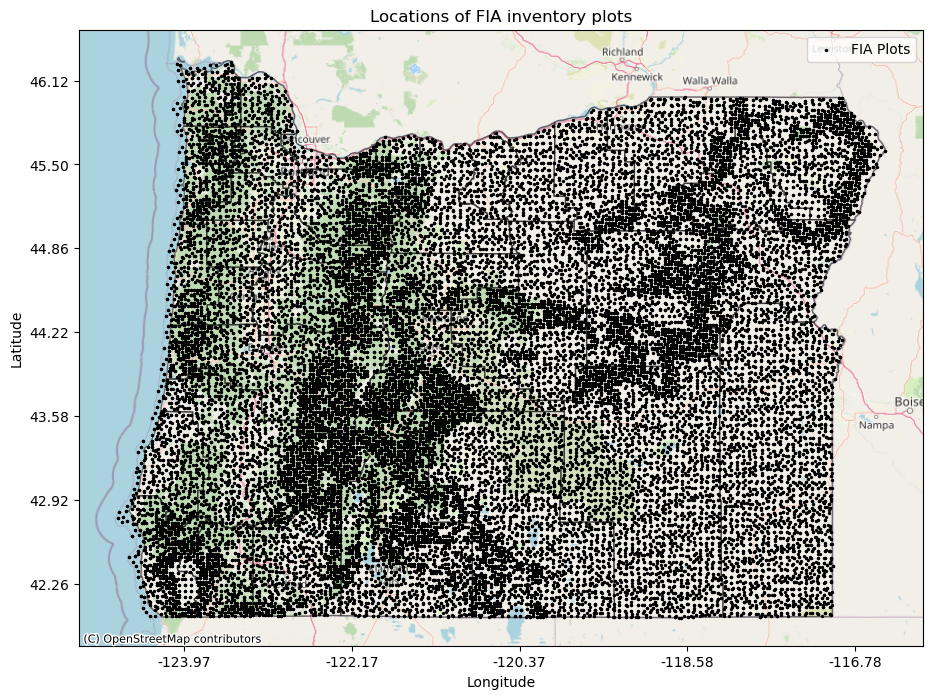

In [16]:
# Visualize all the inventory plots for a given state
# Shows all FIA plots in OR
savefile = f'_Results/{State}_FIA_Plots.png'
vl.plot_map(FIA_Data=FIA_Data, 
            basemap=basemap, 
            FIPS=FIPS, 
            savefile=savefile)

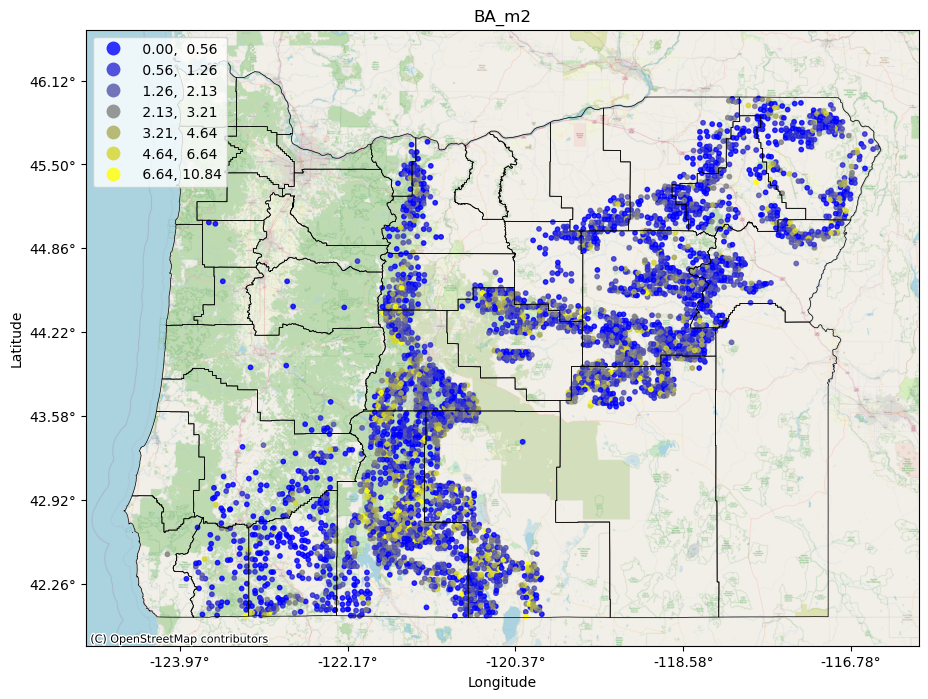

In [23]:
# Statewide plot-level basal area (BA) visualization
# EX) Visualization uses ponderosa pine metrics from above
savefile = f'_Results/{State}_BA.png'
data     = '_Results/OR_Plot_Structure_Indices.csv' # From "STATEWIDE PLOT-LEVEL FOREST ANALYSES"
var      = 'BA_m2'
vl.plot_forest_map(data=data,
                   var=var,
                   basemap=basemap,
                   FIPS=FIPS,
                   savefile=savefile)
# Only plots with ponderosa pine are displayed

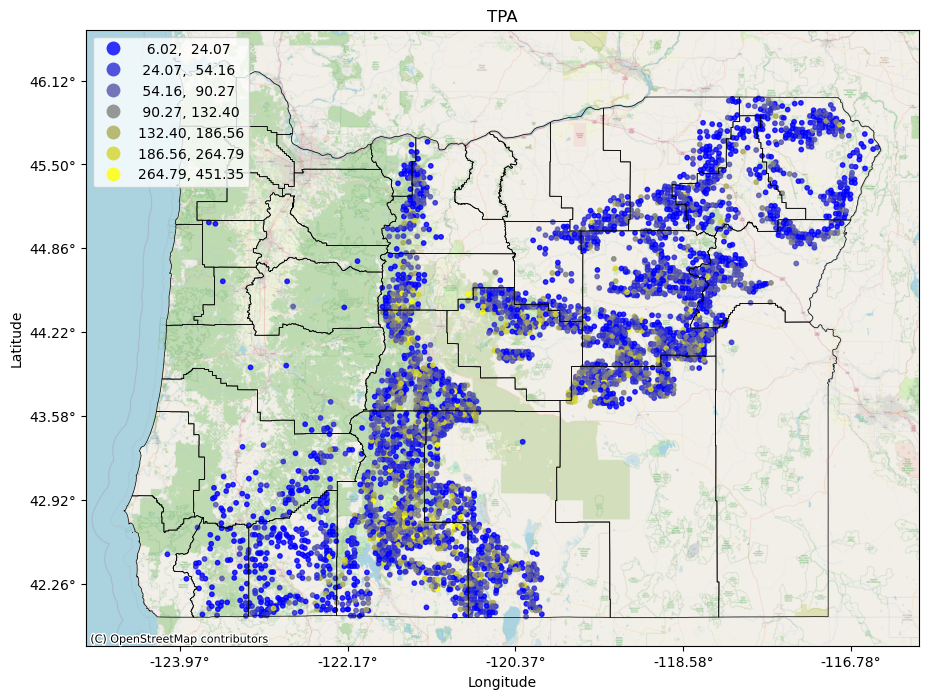

In [24]:
# Statewide plot-level trees per acre (TPA) visualization
# EX) Visualization uses ponderosa pine metrics from above
savefile = f'_Results/{State}_TPA.png'
data     = '_Results/OR_Plot_Structure_Indices.csv'
var      = 'TPA'
vl.plot_forest_map(data=data,
                   var=var,
                   basemap=basemap,
                   FIPS=FIPS,
                   savefile=savefile)
# Only plots with ponderosa pine are displayed

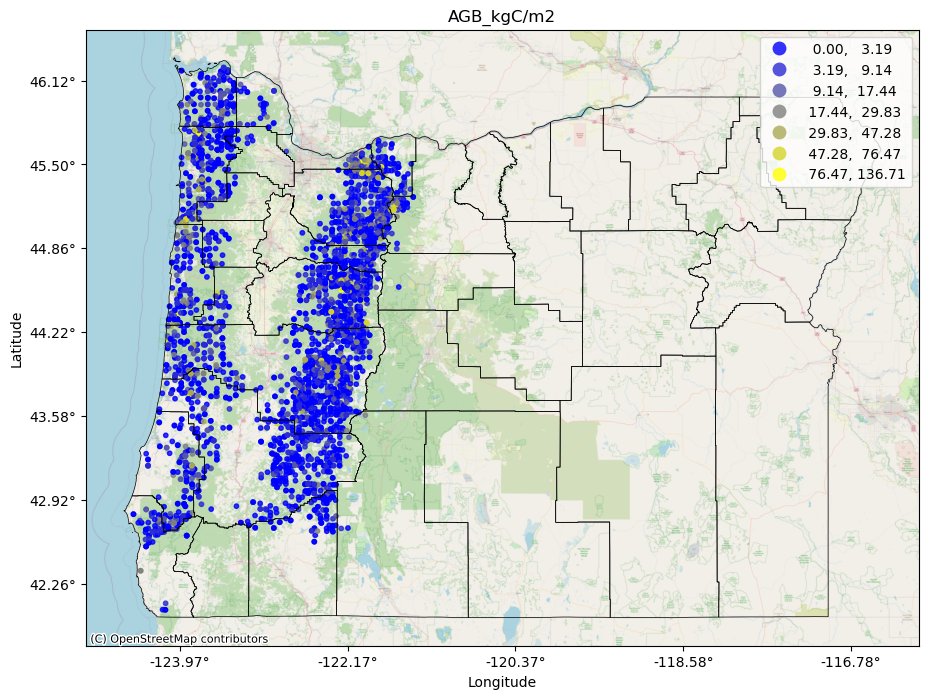

In [22]:
# Statewide plot-level above ground biomass (AGB) visualization
# EX) Displays only Western hemlock species group (from above)
savefile = f'_Results/{State}_AGB.png'    # Added in Western hemlock descriptor
data     = '_Results/OR_Plot_Biomass.csv' # From "STATEWIDE PLOT-LEVEL FOREST ANALYSES"
var      = 'AGB_kgC/m2'
vl.plot_forest_map(data=data,
                   var=var,
                   basemap=basemap,
                   FIPS=FIPS,
                   savefile=savefile)
# Only displays FIA plots classified as Western hemlock spp. group

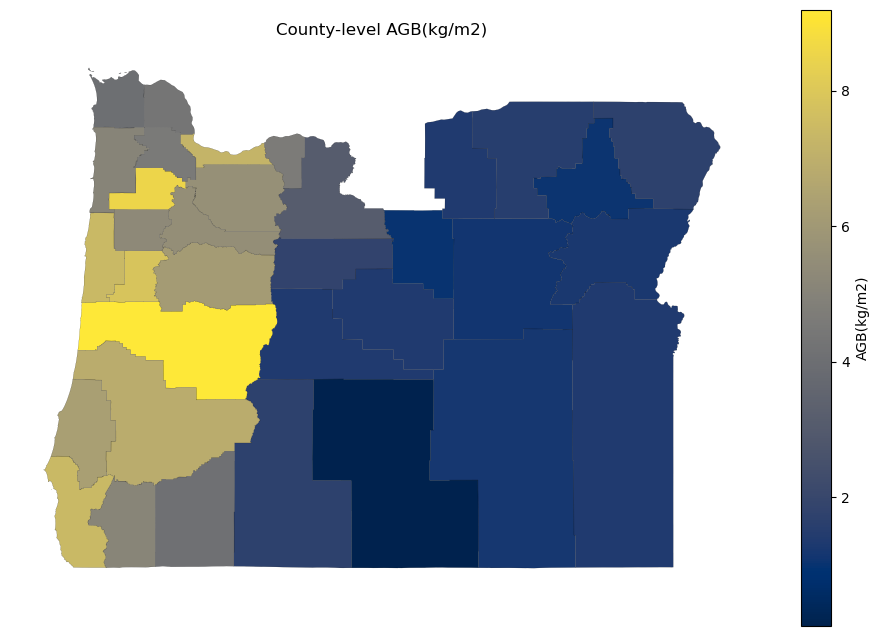

In [20]:
# County-level forest carbon density visualization
# Visualizes data by county instead of FIA plot 
# EX) Displays Douglas-fir biomass per county (from above)
savefile = f'_Results/{State}_County_Biomass_Density.png'
data     = '_Results/OR_County_Biomass_Density.csv' # From "FOREST BIOMASS SUMMARY (BY STATE AND COUNTY)"
var      = 'AGB(kg/m2)'
vl.county_biomass_map(data=data,
                      var=var,
                      basemap=basemap,
                      FIPS=FIPS,
                      savefile=savefile)